In [84]:
import pandas as pd

import os, sys
import matplotlib.pyplot as plt

sys.path.insert(0, "../../")

from spec.enums import MainTableColumns as Cols

In [85]:
# base_dir = '../../../sample_data/cwo/s19/analysis/'
# base_dir = '../../../sample_data/cwo/f19/analysis/'
base_dir = '../../../sample_data/codebench/2024/analysis/'

In [86]:
data = pd.read_csv(os.path.join(base_dir, 'subject_features.csv'))

In [87]:
data.head()

,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,EndTime_sum,Attempts_sum,FirstCorrect_sum,EverCorrect_sum,Attempted_sum,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,Grade
0,28270295,-0.100588,-0.290208,-0.178658,-0.642665,-0.731621,-0.836568,0.596706,-0.969685,-0.665842,...,-1.056546,-0.968186,1.422852,0.403406,0.377579,0.709004,2.127136,1.857665,-1.030587,7.49
1,30783136,-0.993552,-1.258418,-1.115466,-0.740103,-1.062024,0.005973,0.091336,-0.075839,0.230535,...,-0.004118,0.041295,-0.843265,-0.955538,-0.975029,-0.345680,-0.046994,0.061550,-0.029873,8.31
2,105980555,-0.541978,-0.714607,-0.637945,-0.542461,-0.028987,-1.009072,-0.513831,-1.020542,-0.705742,...,-0.623612,-0.568304,-0.591474,-0.898916,-0.749594,-1.801542,-0.429562,-0.637158,-0.628309,1.25
3,141341221,-0.730157,-0.634318,-0.709504,-0.414701,-0.129385,-0.950560,0.209107,-0.988809,0.147420,...,-0.951952,0.022969,-0.087893,-0.049575,0.095786,-0.575244,-0.334250,-0.409018,0.114009,5.91
4,153511603,0.097531,0.089083,0.106438,-0.073279,-0.519774,-0.089131,0.583240,-0.153101,0.841654,...,-0.124147,1.054828,-0.423614,0.743143,0.659372,0.766900,-1.809747,-1.510994,0.865963,6.48


In [88]:
X = data.drop(columns=[Cols.SubjectID, 'Grade'])
y = data['Grade']

In [89]:
# Drop columns with 0 variance
variance = X.var()
zero_variance_cols = variance[variance == 0].index
print (f"Dropping columns with zero variance: {zero_variance_cols.tolist()}")
X = X.drop(columns=zero_variance_cols)

Dropping columns with zero variance: []


In [90]:
linear_corr = X.corr()
# Find pairs that have correlation above 0.9
corr_pairs = linear_corr[linear_corr != 1].stack().reset_index()
corr_pairs.columns = ['Feature1', 'Feature2', 'Correlation']
high_corr_pairs = corr_pairs[abs(corr_pairs['Correlation']) > 0.9].reset_index(drop=True)
print("High correlation pairs:")
with pd.option_context('display.max_rows', None):
    print(high_corr_pairs)

High correlation pairs:
                       Feature1                     Feature2  Correlation
0               ActiveTime_mean               TotalTime_mean     0.962790
1              PassiveTime_mean               TotalTime_mean     0.922011
2                TotalTime_mean              ActiveTime_mean     0.962790
3                TotalTime_mean             PassiveTime_mean     0.922011
4   ActiveTimeAfterCorrect_mean   ActiveTimeAfterCorrect_sum     0.916969
5                StartTime_mean                 EndTime_mean     0.983260
6         FirstCorrectTime_mean             EverCorrect_mean     0.930991
7         FirstCorrectTime_mean                MaxScore_mean     0.998436
8                  EndTime_mean               StartTime_mean     0.983260
9                 Attempts_mean           TotalAttempts_mean     0.978652
10            FirstCorrect_mean                MinScore_mean     0.982899
11            FirstCorrect_mean               MeanScore_mean     0.956636
12            

<Axes: >

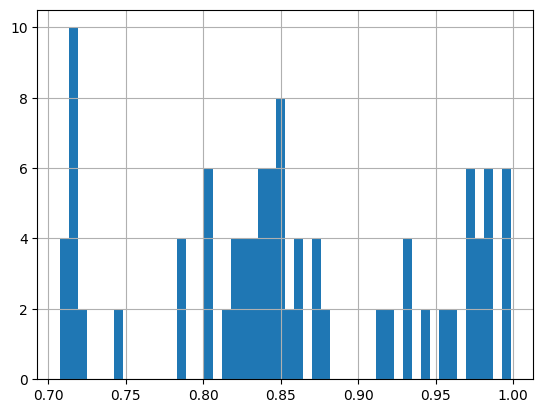

In [91]:
corr_pairs.Correlation[corr_pairs.Correlation > 0.7].hist(bins=50)

In [93]:
# For each highly correlated pair of features, drop the one with the lower
# correlation with the target variable
def drop_low_corr_feature(pair, X, y):
    feature1, feature2 = pair['Feature1'], pair['Feature2']
    corr1 = X[feature1].corr(y)
    corr2 = X[feature2].corr(y)
    if abs(corr1) > abs(corr2):
        return feature2
    else:
        return feature1

to_drop = high_corr_pairs.apply(drop_low_corr_feature, axis=1, X=X, y=y)
print(f"Dropping features with high correlation: {to_drop.tolist()}")
X_lean = X.drop(columns=to_drop)

Dropping features with high correlation: ['ActiveTime_mean', 'TotalTime_mean', 'ActiveTime_mean', 'TotalTime_mean', 'ActiveTimeAfterCorrect_sum', 'EndTime_mean', 'EverCorrect_mean', 'FirstCorrectTime_mean', 'EndTime_mean', 'TotalAttempts_mean', 'FirstCorrect_mean', 'FirstCorrect_mean', 'EverCorrect_mean', 'EverCorrect_mean', 'FirstCorrectTime_mean', 'EverCorrect_mean', 'FirstCorrect_mean', 'MinScore_mean', 'FirstCorrect_mean', 'MinScore_mean', 'TotalAttempts_mean', 'ActiveTime_sum', 'TotalTime_sum', 'ActiveTime_sum', 'TotalTime_sum', 'ActiveTimeAfterCorrect_sum', 'EndTime_sum', 'MaxScore_sum', 'EndTime_sum', 'TotalAttempts_sum', 'Attempted_sum', 'Attempted_sum', 'MaxScore_sum', 'MinScore_sum', 'MinScore_sum', 'TotalAttempts_sum']


In [94]:
X_lean.columns

Index(['PassiveTime_mean', 'ActiveTimeAfterCorrect_mean', '#Breaks_mean',
       'StartTime_mean', 'Attempts_mean', 'Attempted_mean', 'MaxScore_mean',
       'MeanScore_mean', 'PassiveTime_sum', '#Breaks_sum', 'StartTime_sum',
       'FirstCorrectTime_sum', 'Attempts_sum', 'FirstCorrect_sum',
       'EverCorrect_sum', 'MeanScore_sum'],
      dtype='object')

In [95]:
data.drop(columns=to_drop).drop(columns=[Cols.SubjectID]).corr(method='spearman')

,PassiveTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,Attempts_mean,Attempted_mean,MaxScore_mean,MeanScore_mean,PassiveTime_sum,#Breaks_sum,StartTime_sum,FirstCorrectTime_sum,Attempts_sum,FirstCorrect_sum,EverCorrect_sum,MeanScore_sum,Grade
PassiveTime_mean,1.000000,0.334159,0.728714,0.430268,0.510944,-0.418135,-0.509741,-0.592703,0.908161,0.686689,0.455052,-0.456990,0.444413,-0.253631,-0.091012,-0.556193,-0.229008
ActiveTimeAfterCorrect_mean,0.334159,1.000000,0.318826,0.085719,0.388418,0.127384,0.092271,-0.136218,0.247015,0.198437,0.101939,0.127330,0.164630,0.212975,0.368196,-0.129490,0.224144
#Breaks_mean,0.728714,0.318826,1.000000,0.343044,0.509937,-0.343102,-0.422468,-0.451408,0.679223,0.876997,0.387516,-0.378711,0.373647,-0.061790,0.078905,-0.472514,-0.121358
StartTime_mean,0.430268,0.085719,0.343044,1.000000,0.158828,-0.302304,-0.441366,-0.292272,0.475022,0.394148,0.908004,-0.410690,0.209599,-0.216604,-0.198814,-0.303007,-0.255289
Attempts_mean,0.510944,0.388418,0.509937,0.158828,1.000000,-0.008147,-0.163959,-0.657269,0.434195,0.406804,0.177238,-0.121569,0.814246,-0.205022,0.146099,-0.688769,0.051412
Attempted_mean,-0.418135,0.127384,-0.343102,-0.302304,-0.008147,1.000000,0.777357,0.482889,-0.424571,-0.380682,-0.273998,0.663032,-0.086594,0.304104,0.316662,0.385645,0.350607
MaxScore_mean,-0.509741,0.092271,-0.422468,-0.441366,-0.163959,0.777357,1.000000,0.687678,-0.542630,-0.501818,-0.408889,0.914688,-0.293762,0.539830,0.534038,0.580820,0.607718
MeanScore_mean,-0.592703,-0.136218,-0.451408,-0.292272,-0.657269,0.482889,0.687678,1.000000,-0.580672,-0.488585,-0.296094,0.610407,-0.740434,0.628859,0.319294,0.911141,0.407792
PassiveTime_sum,0.908161,0.247015,0.679223,0.475022,0.434195,-0.424571,-0.542630,-0.580672,1.000000,0.773006,0.521871,-0.567287,0.499871,-0.405100,-0.246340,-0.621974,-0.331515
#Breaks_sum,0.686689,0.198437,0.876997,0.394148,0.406804,-0.380682,-0.501818,-0.488585,0.773006,1.000000,0.449131,-0.523030,0.438267,-0.304765,-0.181776,-0.522958,-0.303108


In [45]:
X_lean.corr()

,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,FirstCorrectTime_mean,TotalAttempts_mean,EndTime_sum,FirstCorrect_sum,EverCorrect_sum,MaxScore_sum
PassiveTime_mean,1.000000,0.849811,0.091874,0.524230,-0.227284,0.515597,-0.015158,-0.399487,-0.190580,-0.266426
TotalTime_mean,0.849811,1.000000,0.222675,0.556186,-0.281665,0.858984,-0.025500,-0.607348,-0.246270,-0.266184
ActiveTimeAfterCorrect_mean,0.091874,0.222675,1.000000,0.010519,0.055130,0.362908,0.005681,-0.145599,0.012258,0.060885
#Breaks_mean,0.524230,0.556186,0.010519,1.000000,-0.269840,0.539758,-0.094806,-0.364977,-0.185246,-0.260851
FirstCorrectTime_mean,-0.227284,-0.281665,0.055130,-0.269840,1.000000,-0.255251,-0.153000,0.330117,0.638677,0.828222
TotalAttempts_mean,0.515597,0.858984,0.362908,0.539758,-0.255251,1.000000,-0.063383,-0.652811,-0.233791,-0.203301
EndTime_sum,-0.015158,-0.025500,0.005681,-0.094806,-0.153000,-0.063383,1.000000,0.051693,-0.186323,-0.186283
FirstCorrect_sum,-0.399487,-0.607348,-0.145599,-0.364977,0.330117,-0.652811,0.051693,1.000000,0.480123,0.298210
EverCorrect_sum,-0.190580,-0.246270,0.012258,-0.185246,0.638677,-0.233791,-0.186323,0.480123,1.000000,0.542628
MaxScore_sum,-0.266426,-0.266184,0.060885,-0.260851,0.828222,-0.203301,-0.186283,0.298210,0.542628,1.000000


In [96]:
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_lean, y, test_size=0.2, random_state=42)

In [101]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200, 350, 500],
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='neg_mean_squared_error')

grid_search.fit(X_train, y_train)
print("Best parameters found: ", grid_search.best_params_)

Best parameters found:  {'n_estimators': 500}


In [103]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train, y_train)
print("Lasso coefficients: ", lasso.coef_)
print("Lasso intercept: ", lasso.intercept_)


Lasso coefficients:  [ 0.         -0.01898273 -0.1250018   0.52694031  0.59858778 -0.48190452
  1.03088534  0.8013364   0.1505238  -0.08989632 -0.43594919 -0.0253846
 -0.53820143 -0.85329972  2.27036573 -0.        ]
Lasso intercept:  5.22688318446176


In [102]:
from sklearn.metrics import root_mean_squared_error

root_mean_squared_error(y_test, grid_search.predict(X_test))

1.648626356602281

In [104]:
root_mean_squared_error(y_test, lasso.predict(X_test))

1.714814809843193

In [99]:
from sklearn.dummy import DummyRegressor

dummy_regressor = DummyRegressor(strategy='mean')
dummy_regressor.fit(X_train, y_train)
root_mean_squared_error(y_test, dummy_regressor.predict(X_test))

2.256580226236627

<Axes: >

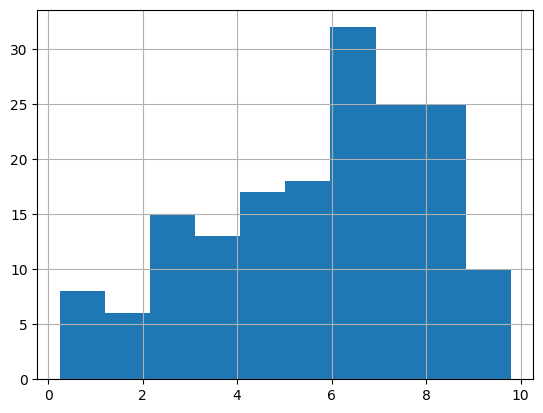

In [100]:
y_train.hist()